# Epigenome Alignment — Benchmark Results
Comparing **V1 (naive DP)** vs **V2 (banded merge DP with gap fallback)** across four synthetic datasets.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

sns.set_theme(style='whitegrid', font_scale=1.15)
COLORS = {'V1': '#4878CF', 'V2': '#E84855'}
DATASETS = ['clean', 'missing_sites', 'extra_sites', 'big_indel']
DATASET_LABELS = ['Clean\n(B = A)', 'Missing Sites\n(10% deletion)', 'Extra Sites\n(5% insertion)', 'Big Indel\n(50 kbp shift)']

with open('../benchmark_results.json') as f:
    raw = json.load(f)

# Flatten into a DataFrame
rows = []
for ds in DATASETS:
    for alg in ('V1', 'V2'):
        m = raw[ds][alg]
        rows.append({
            'dataset': ds, 'alg': alg,
            'f1': m['f1'], 'precision': m['precision'], 'recall': m['recall'],
            'n_tp': m['n_tp'], 'n_fp': m['n_fp'], 'n_fn': m['n_fn'],
            'n_gt': raw[ds]['n_gt_pairs'],
            'runtime_s': m['runtime_s'],
        })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

      dataset alg     f1  precision  recall  n_tp  n_fp  n_fn  n_gt  runtime_s
        clean  V1 1.0000     1.0000  1.0000  2000     0     0  2000      5.015
        clean  V2 1.0000     1.0000  1.0000  2000     0     0  2000    149.127
missing_sites  V1 0.9531     0.9171  0.9922  1780   161    14  1794      4.451
missing_sites  V2 1.0000     1.0000  1.0000  1794     0     0  1794    247.699
  extra_sites  V1 0.9749     0.9523  0.9985  1997   100     3  2000      5.130
  extra_sites  V2 0.9995     0.9995  0.9995  1999     1     1  2000    230.230
    big_indel  V1 1.0000     1.0000  1.0000  2000     0     0  2000      4.841
    big_indel  V2 1.0000     1.0000  1.0000  2000     0     0  2000    147.626


## 1 · Accuracy — F1 / Precision / Recall

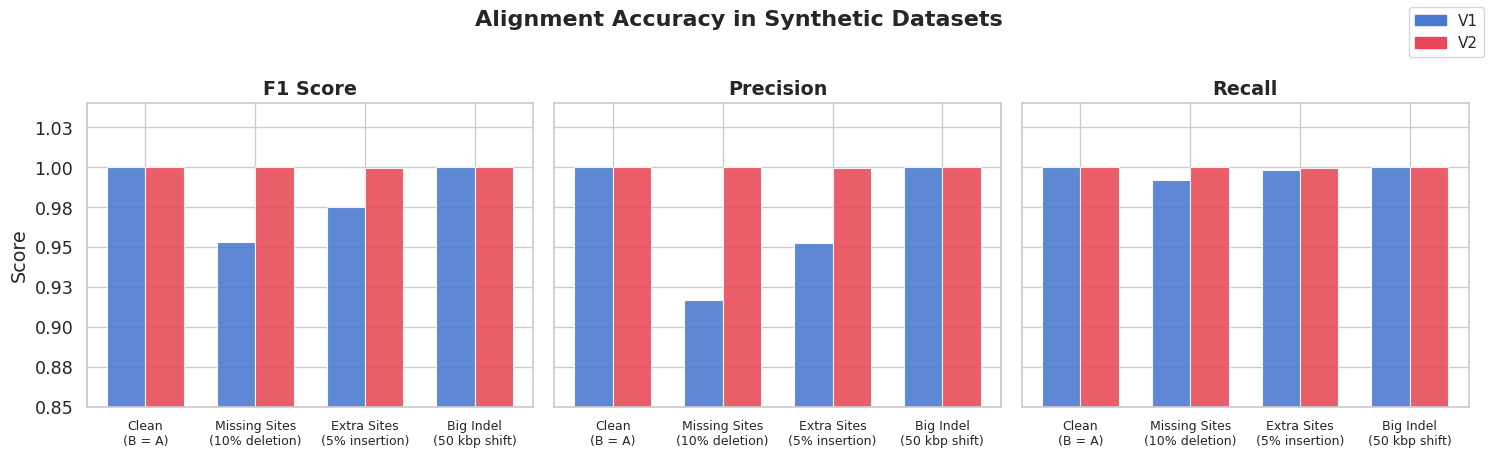

In [10]:
metrics = ['f1', 'precision', 'recall']
metric_labels = ['F1 Score', 'Precision', 'Recall']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

x = np.arange(len(DATASETS))
w = 0.35

for ax, metric, label in zip(axes, metrics, metric_labels):
    for k, alg in enumerate(['V1', 'V2']):
        vals = [raw[ds][alg][metric] for ds in DATASETS]
        bars = ax.bar(x + k*w - w/2, vals, width=w, color=COLORS[alg],
                      label=alg, alpha=0.88, edgecolor='white', linewidth=0.8)
        # for bar, v in zip(bars, vals):
        #     ypos = bar.get_height() - 0.045 if v > 0.96 else bar.get_height() + 0.012
        #     ax.text(bar.get_x() + bar.get_width()/2, ypos,
        #             f'{v:.3f}', ha='center', va='bottom', fontsize=8.5,
        #             color='white' if v > 0.96 else '#333')

    ax.set_title(label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_LABELS, fontsize=9)
    ax.set_ylim(0.85, 1.04)
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

handles = [mpatches.Patch(color=COLORS[a], label=a) for a in ['V1', 'V2']]
fig.legend(handles=handles, loc='upper right', frameon=True, fontsize=11)
fig.suptitle('Alignment Accuracy in Synthetic Datasets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/accuracy_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 2 · Runtime Comparison

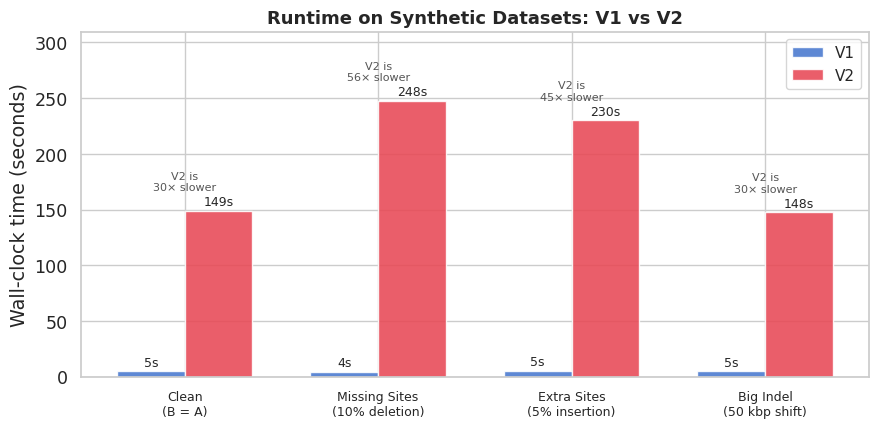

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(DATASETS))
w = 0.35

for k, alg in enumerate(['V1', 'V2']):
    runtimes = [raw[ds][alg]['runtime_s'] for ds in DATASETS]
    bars = ax.bar(x + k*w - w/2, runtimes, width=w, color=COLORS[alg],
                  label=alg, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, runtimes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{v:.0f}s', ha='center', va='bottom', fontsize=9)

# annotate slowdown ratios
for i, ds in enumerate(DATASETS):
    r1 = raw[ds]['V1']['runtime_s']
    r2 = raw[ds]['V2']['runtime_s']
    ratio = r2 / r1
    ax.text(i, max(r1, r2) + 18, f'V2 is\n{ratio:.0f}× slower',
            ha='center', fontsize=8, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(DATASET_LABELS, fontsize=9)
ax.set_ylabel('Wall-clock time (seconds)')
ax.set_title('Runtime on Synthetic Datasets: V1 vs V2', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(raw[ds]['V2']['runtime_s'] for ds in DATASETS) * 1.25)
plt.tight_layout()
plt.savefig('../results/figures/runtime.png', dpi=300, bbox_inches='tight')
plt.show()

## 4 · Summary Heatmap

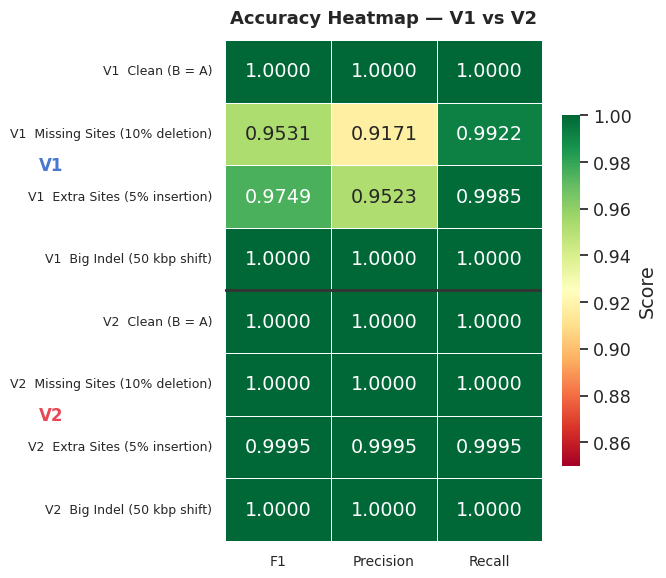

In [5]:
summary_metrics = ['f1', 'precision', 'recall']
summary_labels  = ['F1', 'Precision', 'Recall']

rows_hm, index_hm = [], []
for alg in ['V1', 'V2']:
    for ds, dl in zip(DATASETS, DATASET_LABELS):
        row = [raw[ds][alg][m] for m in summary_metrics]
        rows_hm.append(row)
        index_hm.append(f'{alg}  {dl.replace(chr(10), " ")}')

hm_df = pd.DataFrame(rows_hm, index=index_hm, columns=summary_labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(hm_df, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.85, vmax=1.0, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.7, 'label': 'Score'})
ax.set_title('Accuracy Heatmap — V1 vs V2', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=9, rotation=0)
ax.tick_params(axis='x', labelsize=10)

# Horizontal divider between V1 block and V2 block
ax.axhline(4, color='#333', linewidth=2)
ax.text(-0.55, 2, 'V1', ha='center', va='center', fontsize=12,
        fontweight='bold', color=COLORS['V1'],
        transform=ax.get_yaxis_transform())
ax.text(-0.55, 6, 'V2', ha='center', va='center', fontsize=12,
        fontweight='bold', color=COLORS['V2'],
        transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.savefig('accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Accuracy vs Runtime Trade-off

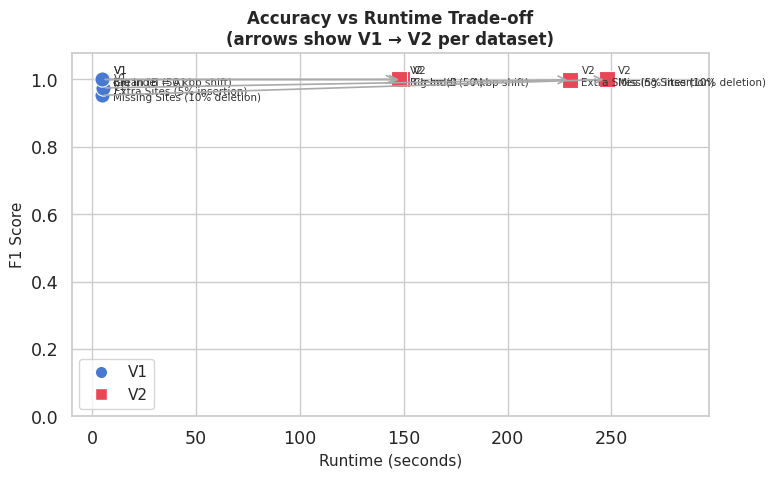

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for alg, marker in [('V1', 'o'), ('V2', 's')]:
    for ds, dl in zip(DATASETS, DATASET_LABELS):
        f1  = raw[ds][alg]['f1']
        rt  = raw[ds][alg]['runtime_s']
        ax.scatter(rt, f1, color=COLORS[alg], marker=marker, s=120,
                   zorder=3, edgecolors='white', linewidths=0.8)
        label_text = dl.replace('\n', ' ')
        ax.annotate(f'{alg}\n{label_text}',
                    xy=(rt, f1), xytext=(8, -4), textcoords='offset points',
                    fontsize=7.5, color='#333')

# Connect V1 → V2 per dataset
for ds in DATASETS:
    x1, y1 = raw[ds]['V1']['runtime_s'], raw[ds]['V1']['f1']
    x2, y2 = raw[ds]['V2']['runtime_s'], raw[ds]['V2']['f1']
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.2))

handles = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['V1'], markersize=9, label='V1'),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=COLORS['V2'], markersize=9, label='V2'),
]
ax.legend(handles=handles, fontsize=11)
ax.set_xlabel('Runtime (seconds)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Accuracy vs Runtime Trade-off\n(arrows show V1 → V2 per dataset)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.0, 1.08)
ax.set_xlim(-10, max(raw[ds]['V2']['runtime_s'] for ds in DATASETS) * 1.2)
plt.tight_layout()
plt.savefig('tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()